In [68]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [69]:
# Load the dataset

with open("census-bureau.columns", "r", encoding="utf-8") as f:
    cols = [line.strip() for line in f if line.strip()]

# 2) Read data using those names
df = pd.read_csv(
    "census-bureau.data",
    header=None,
    names=cols,
    sep=",",
    skipinitialspace=True
)

print(df.shape)
print(df.head())

(199523, 42)
   age                 class of worker  ...  year     label
0   73                 Not in universe  ...    95  - 50000.
1   58  Self-employed-not incorporated  ...    94  - 50000.
2   18                 Not in universe  ...    95  - 50000.
3    9                 Not in universe  ...    94  - 50000.
4   10                 Not in universe  ...    94  - 50000.

[5 rows x 42 columns]


In [70]:
# split the data into features and target variable
X = df.drop("label", axis=1)
y = df["label"]

In [71]:
y.value_counts()

label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

In [72]:
y = y.map({"- 50000.": 0, "50000+.": 1})
print(y.value_counts())

label
0    187141
1     12382
Name: count, dtype: int64


## 1:15 class imbalance, now lets look at our features and separate them into categorical/ordinal and numerical

In [74]:
for col in X.columns:
    print(f"{col}: {X[col].nunique()} unique values")
    print(f"{col}: {X[col].dtype}")
    print(f"{col}: {X[col].isnull().sum()} missing values")

age: 91 unique values
age: int64
age: 0 missing values
class of worker: 9 unique values
class of worker: str
class of worker: 0 missing values
detailed industry recode: 52 unique values
detailed industry recode: int64
detailed industry recode: 0 missing values
detailed occupation recode: 47 unique values
detailed occupation recode: int64
detailed occupation recode: 0 missing values
education: 17 unique values
education: str
education: 0 missing values
wage per hour: 1240 unique values
wage per hour: int64
wage per hour: 0 missing values
enroll in edu inst last wk: 3 unique values
enroll in edu inst last wk: str
enroll in edu inst last wk: 0 missing values
marital stat: 7 unique values
marital stat: str
marital stat: 0 missing values
major industry code: 24 unique values
major industry code: str
major industry code: 0 missing values
major occupation code: 15 unique values
major occupation code: str
major occupation code: 0 missing values
race: 5 unique values
race: str
race: 0 missing v

## Lets treat columns with unique values less than age as categorical/ordinal and the rest as numerical it would be easier to clean and check distributions. Also from the column names those do seem categorical/ordinal

In [75]:
for col in X.columns:
    if X[col].nunique() < X["age"].nunique():
        if(X[col].dtype not in ['category', 'str', 'object']):
            print(f"{col} should be treated as categorical/ordinal")

detailed industry recode should be treated as categorical/ordinal
detailed occupation recode should be treated as categorical/ordinal
num persons worked for employer should be treated as categorical/ordinal
own business or self employed should be treated as categorical/ordinal
veterans benefits should be treated as categorical/ordinal
weeks worked in year should be treated as categorical/ordinal
year should be treated as categorical/ordinal


In [76]:
# All of the above are easily categorical/ordinal except weeks worked in year could be treated as both 
for col in X.columns:
    if X[col].nunique() < X["age"].nunique():
        if(X[col].dtype not in ['category', 'str', 'object']):
            X[col] = X[col].astype("object")

In [77]:
# Now lets split the categorical/ordinal and numerical features for easier cleaning and checking distributions
categorical_cols = [col for col in X.columns if X[col].dtype in ['category', 'str', 'object']]
numerical_cols = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]

In [78]:
print(categorical_cols, numerical_cols)
print(len(categorical_cols), len(numerical_cols), len(X.columns))

['class of worker', 'detailed industry recode', 'detailed occupation recode', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'num persons worked for employer', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefits', 'weeks worked in year', 'year'] ['age', 'wage per hour', 'capital gains', 'capital losses', 'dividends from 

## Lets look at the distribution of numerical features and the unique values of categorical features to check for any data quality issues

In [79]:
df[numerical_cols].describe()

,age,wage per hour,capital gains,capital losses,dividends from stocks,weight
count,199523.000000,199523.000000,199523.00000,199523.000000,199523.000000,199523.000000
mean,34.494199,55.426908,434.71899,37.313788,197.529533,1740.380269
std,22.310895,274.896454,4697.53128,271.896428,1984.163658,993.768156
min,0.000000,0.000000,0.00000,0.000000,0.000000,37.870000
25%,15.000000,0.000000,0.00000,0.000000,0.000000,1061.615000
50%,33.000000,0.000000,0.00000,0.000000,0.000000,1618.310000
75%,50.000000,0.000000,0.00000,0.000000,0.000000,2188.610000
max,90.000000,9999.000000,99999.00000,4608.000000,99999.000000,18656.300000


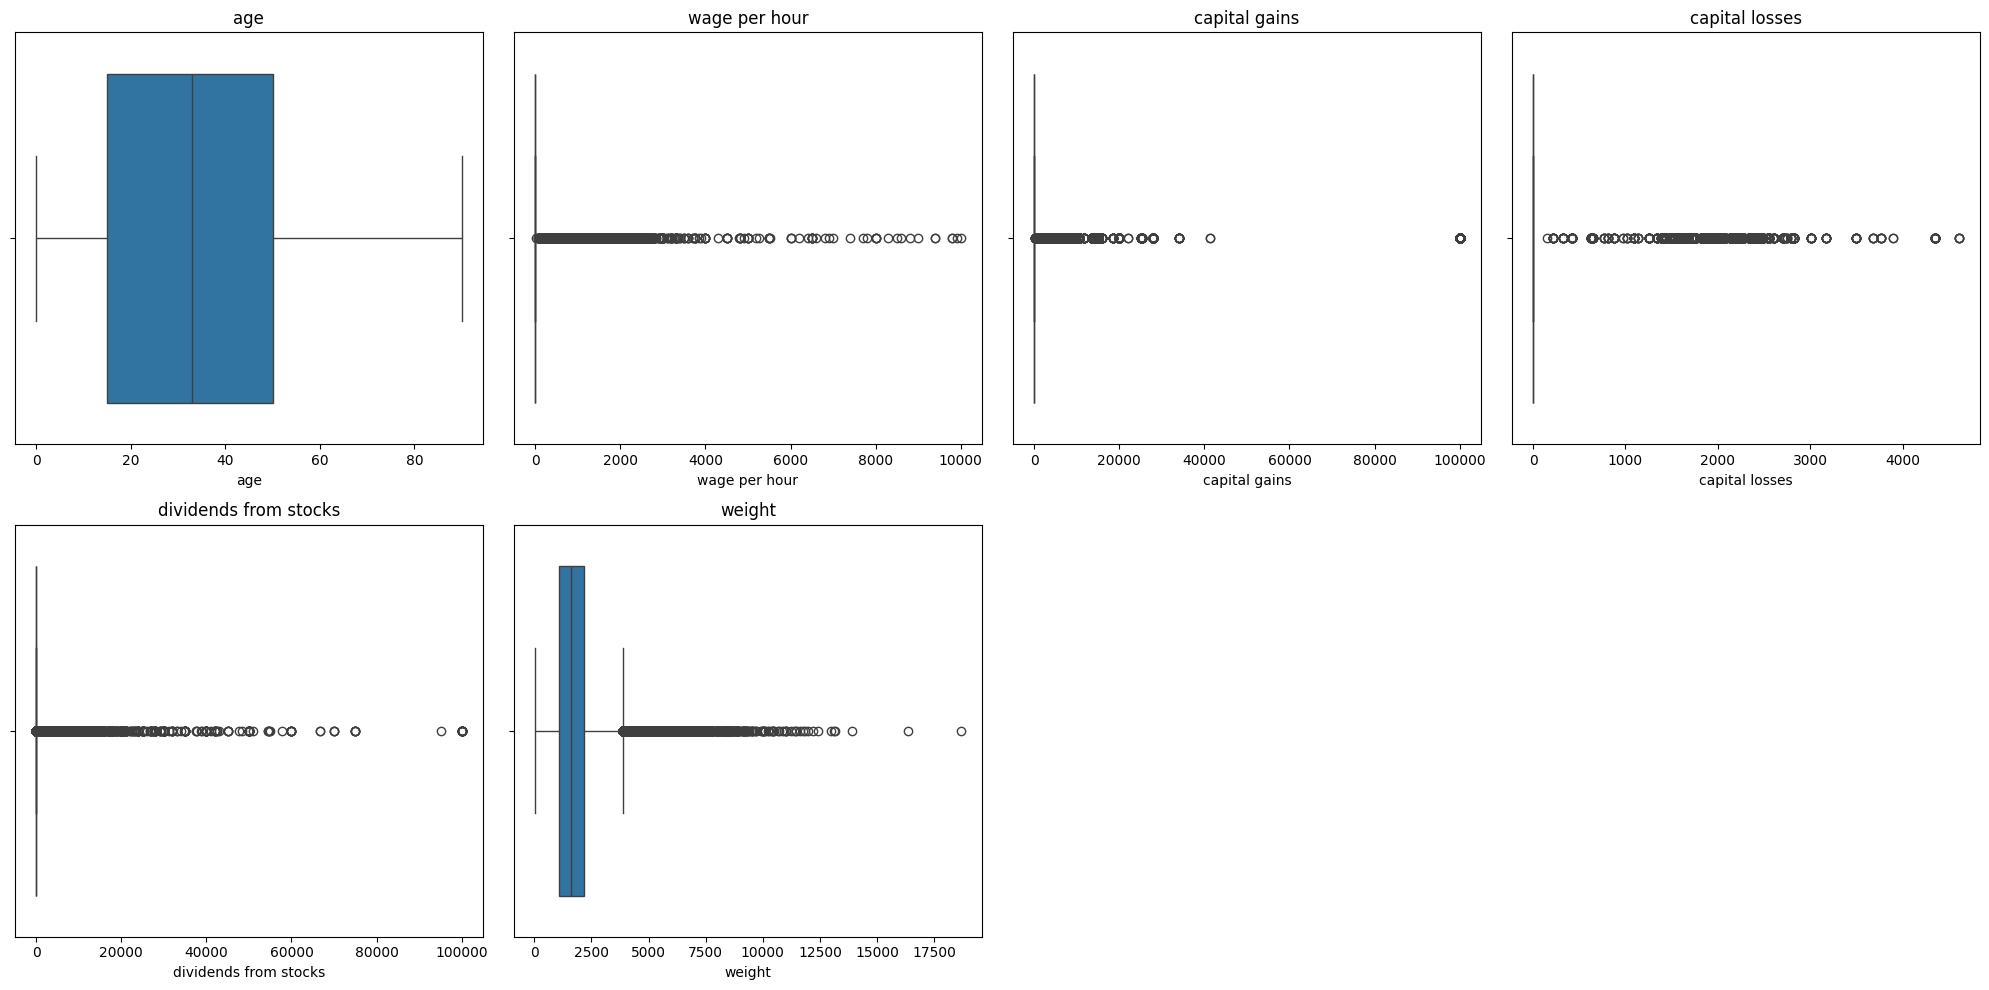

In [80]:
# boxplot to check for outliers in numerical features, all in one plot for easier comparison
plt.figure(figsize=(20, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(x=X[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [81]:
for col in categorical_cols:
    print(f"{col}: {X[col].nunique()} unique values")
    print(f"{col}: {X[col].unique().tolist()}")

class of worker: 9 unique values
class of worker: ['Not in universe', 'Self-employed-not incorporated', 'Private', 'Local government', 'Federal government', 'Self-employed-incorporated', 'State government', 'Never worked', 'Without pay']
detailed industry recode: 52 unique values
detailed industry recode: [0, 4, 40, 34, 43, 37, 24, 39, 12, 35, 45, 3, 19, 29, 32, 48, 33, 23, 44, 36, 31, 30, 41, 5, 11, 9, 42, 6, 18, 50, 2, 1, 26, 47, 16, 14, 22, 17, 7, 8, 25, 46, 27, 15, 13, 49, 38, 21, 28, 20, 51, 10]
detailed occupation recode: 47 unique values
detailed occupation recode: [0, 34, 10, 3, 40, 26, 37, 31, 12, 36, 41, 22, 2, 35, 25, 23, 42, 8, 19, 29, 27, 16, 33, 13, 18, 9, 17, 39, 32, 11, 30, 38, 20, 7, 21, 44, 24, 43, 28, 4, 1, 6, 45, 14, 5, 15, 46]
education: 17 unique values
education: ['High school graduate', 'Some college but no degree', '10th grade', 'Children', 'Bachelors degree(BA AB BS)', 'Masters degree(MA MS MEng MEd MSW MBA)', 'Less than 1st grade', 'Associates degree-academic

## Not in universe means that the subject does not meet the criteria for that question. 
## A column with a lot of "Not in universe" values alludes to the sparsity of data in that column. In the next cell we group them together with ? and np.nan and other variants of "Not in universe" that appear

In [82]:
na_mapping = {'Not in universe', '?', np.nan, 'Not in universe or children',  'Not in universe under 1 year old', 'Not identifiable'}
other_mapping = {'All other'}

X.replace(na_mapping, pd.NA, inplace=True)
X.replace(other_mapping, 'Other', inplace=True)

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year
0,73,NaN,0,0,High school graduate,0,NaN,Widowed,NaN,NaN,White,Other,Female,NaN,NaN,Not in labor force,0,0,0,Nonfiler,NaN,NaN,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,NaN,NaN,0,NaN,United-States,United-States,United-States,Native- Born in the United States,0,NaN,2,0,95
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,NaN,Divorced,Construction,Precision production craft & repair,White,Other,Male,NaN,NaN,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,NaN,United-States,United-States,United-States,Native- Born in the United States,0,NaN,2,52,94
2,18,NaN,0,0,10th grade,0,High school,Never married,NaN,NaN,Asian or Pacific Islander,Other,Female,NaN,NaN,Not in labor force,0,0,0,Nonfiler,NaN,NaN,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,NaN,NaN,0,NaN,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,NaN,2,0,95
3,9,NaN,0,0,Children,0,NaN,Never married,NaN,NaN,White,Other,Female,NaN,NaN,Children or Armed Forces,0,0,0,Nonfiler,NaN,NaN,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,NaN,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,NaN,0,0,94
4,10,NaN,0,0,Children,0,NaN,Never married,NaN,NaN,White,Other,Female,NaN,NaN,Children or Armed Forces,0,0,0,Nonfiler,NaN,NaN,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,NaN,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,NaN,0,0,94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,NaN,0,0,7th and 8th grade,0,NaN,Married-civilian spouse present,NaN,NaN,White,Other,Male,NaN,NaN,Not in labor force,0,0,0,Joint both 65+,NaN,NaN,Householder,Householder,955.27,NaN,NaN,NaN,NaN,NaN,0,NaN,Canada,United-States,United-States,Native- Born in the United States,0,NaN,2,0,95
199519,65,Self-employed-incorporated,37,2,11th grade,0,NaN,Married-civilian spouse present,Business and repair services,Executive admin and managerial,White,Other,Male,NaN,NaN,Children or Armed Forces,6418,0,9,Joint one under 65 & one 65+,NaN,NaN,Householder,Householder,687.19,Nonmover,Nonmover,Nonmover,Yes,NaN,1,NaN,United-States,United-States,United-States,Native- Born in the United States,0,NaN,2,52,94
199520,47,NaN,0,0,Some college but no degree,0,NaN,Married-civilian spouse present,NaN,NaN,White,Other,Male,NaN,NaN,Children or Armed Forces,0,0,157,Joint both under 65,NaN,NaN,Householder,Householder,1923.03,NaN,NaN,NaN,NaN,NaN,6,NaN,Poland,Poland,Germany,Foreign born- U S citizen by naturalization,0,NaN,2,52,95
199521,16,NaN,0,0,10th grade,0,High school,Never married,NaN,NaN,White,Other,Female,NaN,NaN,Not in labor force,0,0,0,Nonfiler,NaN,NaN,Child <18 never marr not in subfamily,Child under 18 never married,466

In [83]:
# Check number of missing values after replacement normalized
print(f"{X.isnull().mean()*100}% missing values in the dataset after replacement")

age                                            0.000000
class of worker                               50.242328
detailed industry recode                       0.000000
detailed occupation recode                     0.000000
education                                      0.000000
wage per hour                                  0.000000
enroll in edu inst last wk                    93.694962
marital stat                                   0.000000
major industry code                           50.462353
major occupation code                         50.462353
race                                           0.000000
hispanic origin                                0.438045
sex                                            0.000000
member of a labor union                       90.445212
reason for unemployment                       96.957744
full or part time employment stat              0.000000
capital gains                                  0.000000
capital losses                                 0

In [84]:
# There are three columns with < 5% missing values and a couple with more than 50% lets get rid of those columns
cols_to_drop = X.columns[X.isnull().mean() > 0.5]
print(f"Columns to drop due to high missing values: {cols_to_drop.tolist()}")

Columns to drop due to high missing values: ['class of worker', 'enroll in edu inst last wk', 'major industry code', 'major occupation code', 'member of a labor union', 'reason for unemployment', 'region of previous residence', 'state of previous residence', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'family members under 18', "fill inc questionnaire for veteran's admin"]


In [85]:
X.drop(columns=cols_to_drop, inplace=True)

In [86]:
X.shape

(199523, 26)

In [87]:
# get back categorical and numerical columns after dropping
categorical_cols = [col for col in X.columns if X[col].dtype in ['category', 'str', 'object']]
numerical_cols = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]
print(len(categorical_cols), len(numerical_cols), len(X.columns))

20 6 26


In [88]:
for col in categorical_cols:
    print(f"{col}: {X[col].nunique()} unique values")

detailed industry recode: 52 unique values
detailed occupation recode: 47 unique values
education: 17 unique values
marital stat: 7 unique values
race: 5 unique values
hispanic origin: 9 unique values
sex: 2 unique values
full or part time employment stat: 8 unique values
tax filer stat: 6 unique values
detailed household and family stat: 38 unique values
detailed household summary in household: 8 unique values
num persons worked for employer: 7 unique values
country of birth father: 42 unique values
country of birth mother: 42 unique values
country of birth self: 42 unique values
citizenship: 5 unique values
own business or self employed: 3 unique values
veterans benefits: 3 unique values
weeks worked in year: 53 unique values
year: 2 unique values


In [89]:
# lets look at normalized value counts for the categorical features to see if there are any dominant categories that we can group together
for col in categorical_cols:
    print(f"{col} value counts normalized:")
    print(X[col].value_counts(normalize=True))
    print("\n")

detailed industry recode value counts normalized:
detailed industry recode
0     0.504624
33    0.085554
43    0.041514
4     0.029992
42    0.023471
45    0.022464
29    0.021095
37    0.020158
41    0.019867
32    0.018023
35    0.016940
39    0.014720
34    0.013858
44    0.012775
2     0.011006
11    0.008841
50    0.008540
40    0.008275
47    0.008240
38    0.008164
24    0.007533
12    0.006766
19    0.006746
30    0.005919
31    0.005904
25    0.005433
9     0.004977
22    0.004771
36    0.004736
13    0.004506
1     0.004145
48    0.003268
27    0.003137
49    0.003057
3     0.002822
21    0.002802
6     0.002777
5     0.002772
8     0.002757
16    0.002701
23    0.002631
18    0.002421
15    0.002265
7     0.002115
14    0.001479
46    0.000937
17    0.000787
28    0.000717
26    0.000637
51    0.000180
20    0.000160
10    0.000020
Name: proportion, dtype: float64


detailed occupation recode value counts normalized:
detailed occupation recode
0     0.504624
2     0.043885
2

## Categorical is a lot cleaner now even tho high cardinality. Lets go back to numerical and make sure there are no outliers or data quality issues there.

In [90]:
X[numerical_cols].describe()

,age,wage per hour,capital gains,capital losses,dividends from stocks,weight
count,199523.000000,199523.000000,199523.00000,199523.000000,199523.000000,199523.000000
mean,34.494199,55.426908,434.71899,37.313788,197.529533,1740.380269
std,22.310895,274.896454,4697.53128,271.896428,1984.163658,993.768156
min,0.000000,0.000000,0.00000,0.000000,0.000000,37.870000
25%,15.000000,0.000000,0.00000,0.000000,0.000000,1061.615000
50%,33.000000,0.000000,0.00000,0.000000,0.000000,1618.310000
75%,50.000000,0.000000,0.00000,0.000000,0.000000,2188.610000
max,90.000000,9999.000000,99999.00000,4608.000000,99999.000000,18656.300000


## I think one could make an argument for including or not including age 0 but since this in census data I would like to assume that a parent filled it for a child and that we can keep the data. The label should be - 50000. (0) for those rows tho and even for those <15 I would assume the same. Maybe there a some teens >16 making more than 50000. 

In [91]:
# Lets see the label distribution for those with age <15
print(y[X['age'] < 15].value_counts(normalize=True))

label
0    1.0
Name: proportion, dtype: float64


## Lets create our baseline now since the data is clean

In [92]:
def model_training_and_eval(X, y):
    X_model = X.copy()

    # XGBoost only accepts numeric/bool/category dtypes.
    for col in X_model.columns:
        if pd.api.types.is_object_dtype(X_model[col]) or pd.api.types.is_string_dtype(X_model[col]):
            X_model[col] = X_model[col].astype("category")

    # split the data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_model, y, test_size=0.2, random_state=42)

    # train an XGBoost mode
    model = xgb.XGBClassifier(eval_metric='logloss', enable_categorical=True)
    model.fit(X_train, y_train)

    # make predictions on the test set
    y_pred = model.predict(X_test)

    # evaluate the model
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Main Focus: Macro F1:\n", f1_score(y_test, y_pred, average='macro'))
    return model

In [93]:
print(X.shape, y.shape)

(199523, 26) (199523,)


In [94]:
baseline_model = model_training_and_eval(X, y)

Accuracy: 0.9581756672096229
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     37543
           1       0.72      0.49      0.58      2362

    accuracy                           0.96     39905
   macro avg       0.84      0.74      0.78     39905
weighted avg       0.95      0.96      0.95     39905

Confusion Matrix:
 [[37087   456]
 [ 1213  1149]]
Main Focus: Macro F1:
 0.7786365330651797


Top 20 features by gain:


Top 20 features by gain:


,gain
capital gains,132.394714
sex,71.633354
detailed occupation recode,57.217583
tax filer stat,31.166698
weeks worked in year,31.148788
dividends from stocks,28.862383
education,25.624100
age,16.648588
capital losses,16.377125
detailed household and family stat,11.984111


Top 20 features by gain:


,gain
capital gains,132.394714
sex,71.633354
detailed occupation recode,57.217583
tax filer stat,31.166698
weeks worked in year,31.148788
dividends from stocks,28.862383
education,25.624100
age,16.648588
capital losses,16.377125
detailed household and family stat,11.984111


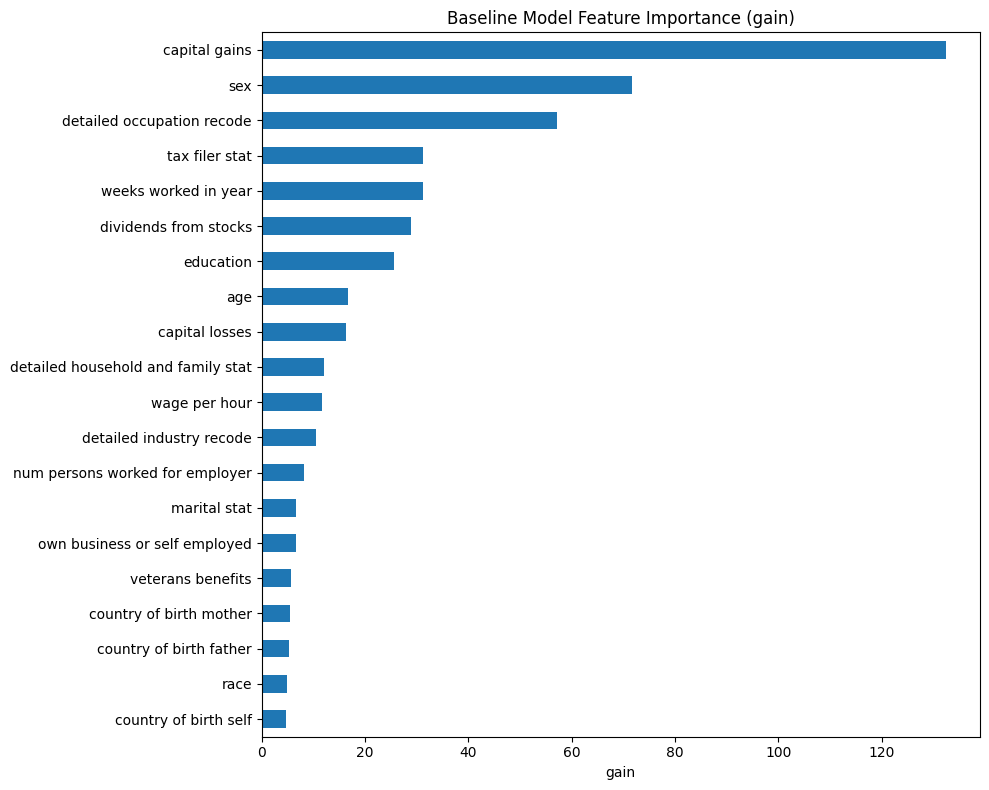

In [95]:
# Feature importance from the trained baseline model
# importance_type options: "weight", "gain", "cover", "total_gain", "total_cover"
importance_type = "gain"

booster = baseline_model.get_booster()
raw_importance = booster.get_score(importance_type=importance_type)

# Include every input feature and fill unused ones with 0 importance
feature_importance = (
    pd.Series(raw_importance)
    .reindex(X.columns, fill_value=0)
    .sort_values(ascending=False)
)

print(f"Top 20 features by {importance_type}:")
display(feature_importance.head(20).to_frame(name=importance_type))

plt.figure(figsize=(10, 8))
feature_importance.head(20).sort_values().plot(kind="barh")
plt.title(f"Baseline Model Feature Importance ({importance_type})")
plt.xlabel(importance_type)
plt.tight_layout()
plt.show()

## It is very interesting that wage per hour is not a significant feature in the baseline model. I would have expected it to be since it is a direct measure of income but maybe it is not as important as other features like occupation or education. It could also be that there are a lot of missing values in that column which could be affecting the model's performance.

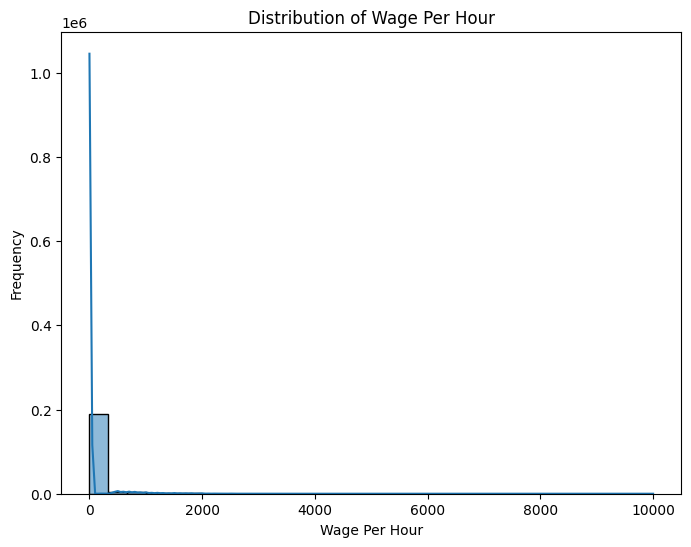

In [97]:
# plot wage per hour
plt.figure(figsize=(8, 6))
sns.histplot(X['wage per hour'], bins=30, kde=True)
plt.title('Distribution of Wage Per Hour')
plt.xlabel('Wage Per Hour')
plt.ylabel('Frequency')
plt.show()

In [99]:
X.columns

Index(['age', 'detailed industry recode', 'detailed occupation recode',
       'education', 'wage per hour', 'marital stat', 'race', 'hispanic origin',
       'sex', 'full or part time employment stat', 'capital gains',
       'capital losses', 'dividends from stocks', 'tax filer stat',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'num persons worked for employer', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'own business or self employed', 'veterans benefits',
       'weeks worked in year', 'year'],
      dtype='str')

In [100]:
X['full or part time employment stat'].value_counts()

full or part time employment stat
Children or Armed Forces              123769
Full-time schedules                    40736
Not in labor force                     26808
PT for non-econ reasons usually FT      3322
Unemployed full-time                    2311
PT for econ reasons usually PT          1209
Unemployed part- time                    843
PT for econ reasons usually FT           525
Name: count, dtype: int64

In [102]:
# lets see the wage distribution of Children or Armed Forces
X[X['full or part time employment stat'].isin(['Children or Armed Forces'])]['wage per hour'].value_counts()

wage per hour
0       118102
500        399
800        281
700        272
600        254
         ...  
1728         1
1584         1
1129         1
1376         1
1057         1
Name: count, Length: 881, dtype: int64

In [127]:
# Full time is 35 hours a week and 52 weeks a year according to the census bureau, so we can calculate the wage per year for each individual and see if it has any correlation with the label. For part time workers we can assume they work half the hours of full time workers.
wage_per_year = []
for index, row in X.iterrows():
    temp_wage_per_year = row['wage per hour'] * 35 * row['weeks worked in year']
    if 'PT' in row['full or part time employment stat']:
        wage_per_year.append(temp_wage_per_year/2)
    else:
        wage_per_year.append(temp_wage_per_year)

In [128]:
# lets see the distribution of wage per year and our target

df_wage_per_year = pd.DataFrame({'wage_per_year': wage_per_year, 'label': y})

print(df_wage_per_year[(df_wage_per_year['wage_per_year'] > 0) & (df_wage_per_year['label'] == 0)].describe(), 
df_wage_per_year[(df_wage_per_year['wage_per_year'] > 0) & (df_wage_per_year['label'] == 1)].describe(), sep="\n\n")


       wage_per_year    label
count   1.046700e+04  10467.0
mean    1.514009e+06      0.0
std     1.095889e+06      0.0
min     7.525000e+03      0.0
25%     8.820000e+05      0.0
50%     1.302000e+06      0.0
75%     1.941030e+06      0.0
max     1.804712e+07      0.0

       wage_per_year  label
count   5.540000e+02  554.0
mean    3.169564e+06    1.0
std     1.768250e+06    0.0
min     6.562500e+04    1.0
25%     1.943305e+06    1.0
50%     3.198650e+06    1.0
75%     4.004000e+06    1.0
max     1.819818e+07    1.0


In [115]:
df.columns

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'education', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'hispanic origin', 'sex',
       'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'capital gains', 'capital losses',
       'dividends from stocks', 'tax filer stat',
       'region of previous residence', 'state of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'migration code-change in msa', 'migration code-change in reg',
       'migration code-move within reg', 'live in this house 1 year ago',
       'migration prev res in sunbelt', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'ow

In [116]:
X.columns

Index(['age', 'detailed industry recode', 'detailed occupation recode',
       'education', 'wage per hour', 'marital stat', 'race', 'hispanic origin',
       'sex', 'full or part time employment stat', 'capital gains',
       'capital losses', 'dividends from stocks', 'tax filer stat',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'num persons worked for employer', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'own business or self employed', 'veterans benefits',
       'weeks worked in year', 'year'],
      dtype='str')

In [232]:
X['capital gains'].describe()

count    199523.00000
mean        434.71899
std        4697.53128
min           0.00000
25%           0.00000
50%           0.00000
75%           0.00000
max       99999.00000
Name: capital gains, dtype: float64

In [233]:
# Gains and wages are capped at 99k and 9.9k respectively.

In [237]:
# Check duplicate rows
print(f"Number of duplicate rows: {X.duplicated().sum()}")

Number of duplicate rows: 4637


In [236]:
df[df['capital gains']==99999]

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
780,47,Private,29,2,Masters degree(MA MS MEng MEd MSW MBA),0,Not in universe,Married-civilian spouse present,Transportation,Executive admin and managerial,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,99999,0,33,Joint both under 65,Not in universe,Not in universe,Householder,Householder,1698.04,Nonmover,Nonmover,Nonmover,Yes,Not in universe,4,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,50000+.
811,33,Private,9,36,High school graduate,0,Not in universe,Married-civilian spouse present,Manufacturing-durable goods,Machine operators assmblrs & inspctrs,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,99999,0,0,Joint both under 65,Not in universe,Not in universe,Householder,Householder,1844.53,Nonmover,Nonmover,Nonmover,Yes,Not in universe,2,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,50000+.
833,34,Private,35,17,Bachelors degree(BA AB BS),0,Not in universe,Never married,Finance insurance and real estate,Sales,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,99999,0,13000,Single,Not in universe,Not in universe,Nonfamily householder,Householder,228.18,Nonmover,Nonmover,Nonmover,Yes,Not in universe,3,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,39,94,50000+.
1043,41,Private,34,17,Masters degree(MA MS MEng MEd MSW MBA),0,Not in universe,Married-civilian spouse present,Finance insurance and real estate,Sales,White,All other,Male,Not in universe,Not in universe,Full-time schedules,99999,0,50,Joint both under 65,Not in universe,Not in universe,Householder,Householder,2528.23,?,?,?,Not in universe under 1 year old,?,6,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,95,50000+.
1713,56,Self-employed-incorporated,42,7,Doctorate degree(PhD EdD),0,Not in universe,Married-civilian spouse present,Medical except hospital,Professional specialty,White,All other,Male,Not in universe,Not in universe,Full-time schedules,99999,0,2000,Joint both under 65,Not in universe,Not in universe,Householder,Householder,1209.24,?,?,?,Not in universe under 1 year old,?,2,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,95,50000+.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198876,60,Self-employed-incorporated,45,11,Doctorate degree(PhD EdD),0,Not in universe,Married-civilian spouse present,Other professional services,Professional specialty,White,All other,Male,Not in universe,Not in universe,Full-time schedules,99999,0,0,Joint both under 65,Not in universe,Not in universe,Householder,Householder,666.13,?,?,?,Not in universe under 1 year old,?,1,Not in universe,United-States,United-States,United-States,Native- Born in the United

In [235]:
df[df['wage per hour']==9999]

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
190936,46,Private,45,11,Doctorate degree(PhD EdD),9999,Not in universe,Never married,Other professional services,Professional specialty,White,All other,Male,No,Not in universe,Children or Armed Forces,0,0,0,Single,Not in universe,Not in universe,Nonfamily householder,Householder,3434.01,Nonmover,Nonmover,Nonmover,Yes,Not in universe,3,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,50000+.


In [ ]:
# Now we can also have a column that includes capital gain and capital loss to see if that has any correlation with the label since it is a direct measure of income as well. We can also do some EDA on that column to see if there are any outliers or if it is skewed. We can also check the correlation of that column with the label to see if it is a good feature to include in our model.

df_wage_per_year['total_income'] =  X['dividends from stocks'] + df_wage_per_year['wage_per_year']

print(df_wage_per_year[df_wage_per_year['label'] == 0].describe(), df_wage_per_year[df_wage_per_year['label'] == 1].describe(), sep="\n\n")

# plot total income distribution as a box plot for 0 and 1 label



       wage_per_year     label  total_income
count   1.871410e+05  187141.0  1.871410e+05
mean    8.468017e+04       0.0  2.016323e+05
std     4.338227e+05       0.0  1.887118e+06
min     0.000000e+00       0.0 -4.608000e+06
25%     0.000000e+00       0.0  0.000000e+00
50%     0.000000e+00       0.0  0.000000e+00
75%     0.000000e+00       0.0  0.000000e+00
max     1.804712e+07       0.0  1.023619e+08

       wage_per_year    label  total_income
count   1.238200e+04  12382.0  1.238200e+04
mean    1.418138e+05      1.0  4.781158e+06
std     7.543649e+05      0.0  1.694753e+07
min     0.000000e+00      1.0 -3.683000e+06
25%     0.000000e+00      1.0  0.000000e+00
50%     0.000000e+00      1.0  1.200000e+01
75%     0.000000e+00      1.0  1.200000e+04
max     1.819818e+07      1.0  1.060085e+08


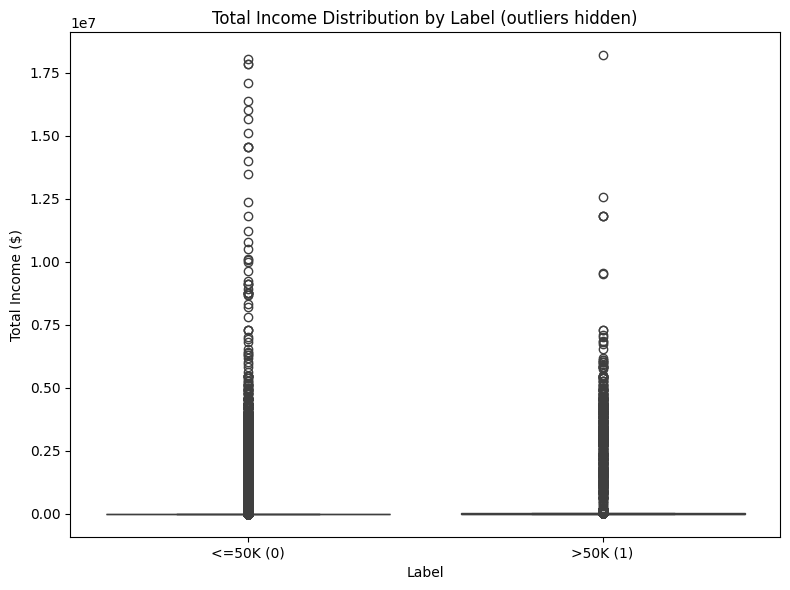

          count           mean            std  ...   50%     75%         max
label                                          ...                          
0      187141.0   84904.833372  433841.267323  ...   0.0     0.0  18047120.0
1       12382.0  148005.017041  753926.761065  ...  25.0  7298.0  18198180.0

[2 rows x 8 columns]


In [149]:
plot_df = pd.DataFrame({'total_income': df_wage_per_year['total_income'], 'label': y})

plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x='label', y='total_income')
plt.xticks([0, 1], ['<=50K (0)', '>50K (1)'])
plt.title('Total Income Distribution by Label (outliers hidden)')
plt.xlabel('Label')
plt.ylabel('Total Income ($)')
plt.tight_layout()
plt.show()

print(plot_df.groupby('label')['total_income'].describe())

In [150]:
X.columns

Index(['age', 'detailed industry recode', 'detailed occupation recode',
       'education', 'wage per hour', 'marital stat', 'race', 'hispanic origin',
       'sex', 'full or part time employment stat', 'capital gains',
       'capital losses', 'dividends from stocks', 'tax filer stat',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'num persons worked for employer', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'own business or self employed', 'veterans benefits',
       'weeks worked in year', 'year', 'total_income'],
      dtype='str')

## The columns we dropped had like those with 50% Not in Universe values could actually help we should bring them back into X and see if we can see a pattern.

In [151]:
X['detailed household summary in household'].unique()

<ArrowStringArray>
[       'Other relative of householder',
                          'Householder',
                    'Child 18 or older',
         'Child under 18 never married',
                'Spouse of householder',
           'Nonrelative of householder',
 'Group Quarters- Secondary individual',
          'Child under 18 ever married']
Length: 8, dtype: str

In [208]:
# For those with <=50 K but with more than 50k total income, we can check the detailed household summary to see if there are any patterns or commonalities among those individuals. This could help us understand if there are any specific household characteristics that are associated with having a total income greater than 50k but still being labeled as <=50k. We can also check if there are any outliers or if there is any skewness in the total income distribution for those with <=50k label we can check their value counts in other cols

X['total_income'] = df_wage_per_year['total_income']

In [209]:
anomalies_too_high_income_for_lt_50k =X[(X['total_income'] > 50000) & (y == 0)]
anomalies_too_low_income_for_gt_50k = X[(X['total_income'] < 50000) & (y == 1)]

In [210]:
anomalies_too_high_income_for_lt_50k.describe()

,age,wage per hour,capital gains,capital losses,dividends from stocks,weight,total_income
count,14893.000000,14893.000000,14893.000000,14893.000000,14893.000000,14893.000000,1.489300e+04
mean,40.520714,656.001679,1807.551266,9.899752,168.469617,1778.450004,2.853372e+06
std,16.051871,667.738721,6197.180061,131.226925,1273.980723,1006.211666,6.040601e+06
min,15.000000,0.000000,0.000000,0.000000,0.000000,62.370000,5.075000e+04
25%,28.000000,0.000000,0.000000,0.000000,0.000000,1095.520000,1.037400e+06
50%,38.000000,600.000000,0.000000,0.000000,0.000000,1662.530000,1.714560e+06
75%,50.000000,975.000000,2354.000000,0.000000,0.000000,2256.560000,3.094000e+06
max,90.000000,9916.000000,99999.000000,2258.000000,39000.000000,12184.500000,1.023619e+08


In [211]:
anomalies_too_low_income_for_gt_50k.describe()

,age,wage per hour,capital gains,capital losses,dividends from stocks,weight,total_income
count,9468.000000,9468.000000,9468.0,9468.000000,9468.000000,9468.000000,9.468000e+03
mean,45.891424,1.225285,0.0,245.819392,1125.650613,1803.731981,-2.428588e+05
std,11.617602,32.410099,0.0,676.573489,4561.977658,962.110755,6.731969e+05
min,16.000000,0.000000,0.0,0.000000,0.000000,49.820000,-3.683000e+06
25%,37.000000,0.000000,0.0,0.000000,0.000000,1123.557500,0.000000e+00
50%,45.000000,0.000000,0.0,0.000000,0.000000,1688.155000,0.000000e+00
75%,53.000000,0.000000,0.0,0.000000,300.000000,2254.017500,1.750000e+02
max,90.000000,1250.000000,0.0,3683.000000,99999.000000,8432.830000,4.999900e+04


In [212]:
# Subset df by anomalies_too_low_income_for_gt_50k

for col in set(df.columns) - set(X.columns):
    print(df.iloc[anomalies_too_low_income_for_gt_50k.index][col].value_counts(normalize=True))



major industry code
Manufacturing-durable goods            0.118716
Finance insurance and real estate      0.092522
Other professional services            0.084495
Education                              0.077524
Not in universe or children            0.072243
Manufacturing-nondurable goods         0.070976
Public administration                  0.069814
Retail trade                           0.059992
Business and repair services           0.050486
Medical except hospital                0.047000
Wholesale trade                        0.045099
Construction                           0.042248
Transportation                         0.038762
Hospital services                      0.037389
Utilities and sanitary services        0.020384
Communications                         0.020279
Agriculture                            0.014259
Mining                                 0.011407
Entertainment                          0.009083
Personal services except private HH    0.007921
Social services     

In [213]:
for col in set(df.columns) - set(X.columns):
    print(df[col].value_counts(normalize=True))

major industry code
Not in universe or children            0.504624
Retail trade                           0.085554
Manufacturing-durable goods            0.045183
Education                              0.041514
Manufacturing-nondurable goods         0.034567
Finance insurance and real estate      0.030798
Construction                           0.029992
Business and repair services           0.028323
Medical except hospital                0.023471
Public administration                  0.023105
Other professional services            0.022464
Transportation                         0.021095
Hospital services                      0.019867
Wholesale trade                        0.018023
Agriculture                            0.015151
Personal services except private HH    0.014720
Social services                        0.012775
Entertainment                          0.008275
Communications                         0.005919
Utilities and sanitary services        0.005904
Private household se

## We need to bring back major industry code, major occupation code, class of worker

In [214]:
# anomalies_too_low_income_for_gt_50k is more concerning because it is misclassifying the minority class 11k out of 12k times

for col in categorical_cols:
    print(f"Value counts for {col} in anomalies_too_low_income_for_gt_50k:")
    print(anomalies_too_low_income_for_gt_50k[col].value_counts(normalize=True))
    print("\n")

Value counts for detailed industry recode in anomalies_too_low_income_for_gt_50k:
detailed industry recode
45    0.084495
43    0.077524
0     0.072243
33    0.059992
35    0.051014
42    0.047000
32    0.045099
37    0.042776
4     0.042248
34    0.041508
29    0.038762
41    0.037389
11    0.026405
50    0.026088
47    0.025877
25    0.024187
12    0.022497
31    0.020384
30    0.020279
13    0.017005
24    0.014998
49    0.012463
3     0.011407
16    0.010139
9     0.010034
2     0.009928
40    0.009083
15    0.008766
19    0.008027
39    0.007921
38    0.007710
8     0.006760
23    0.006760
44    0.006443
48    0.005387
14    0.005281
27    0.005175
1     0.004330
7     0.004014
26    0.004014
22    0.003380
21    0.002535
5     0.002535
6     0.002324
18    0.002112
46    0.002007
20    0.001373
17    0.000845
51    0.000634
28    0.000528
36    0.000317
Name: proportion, dtype: float64


Value counts for detailed occupation recode in anomalies_too_low_income_for_gt_50k:
detailed 

In [215]:
for cat in categorical_cols:
    print(f"Value counts for {cat} in X:")
    print(X[cat].value_counts(normalize=True))
    print("\n")

Value counts for detailed industry recode in X:
detailed industry recode
0     0.504624
33    0.085554
43    0.041514
4     0.029992
42    0.023471
45    0.022464
29    0.021095
37    0.020158
41    0.019867
32    0.018023
35    0.016940
39    0.014720
34    0.013858
44    0.012775
2     0.011006
11    0.008841
50    0.008540
40    0.008275
47    0.008240
38    0.008164
24    0.007533
12    0.006766
19    0.006746
30    0.005919
31    0.005904
25    0.005433
9     0.004977
22    0.004771
36    0.004736
13    0.004506
1     0.004145
48    0.003268
27    0.003137
49    0.003057
3     0.002822
21    0.002802
6     0.002777
5     0.002772
8     0.002757
16    0.002701
23    0.002631
18    0.002421
15    0.002265
7     0.002115
14    0.001479
46    0.000937
17    0.000787
28    0.000717
26    0.000637
51    0.000180
20    0.000160
10    0.000020
Name: proportion, dtype: float64


Value counts for detailed occupation recode in X:
detailed occupation recode
0     0.504624
2     0.043885
26   

## Okay so this solved the mystery of why detailed occupation code was so important since it makes up only 4% of the data but in the anomalies of too low income for >50k it makes up 23% which is a significant portion of the data. 

In [218]:
# Okay so those who have said they worked 52 weeks in a year and classified >50k but have a total income of majority 0
anomalies_too_low_income_for_gt_50k[(anomalies_too_low_income_for_gt_50k['weeks worked in year'] == 52)]['wage per hour'].value_counts()

wage per hour
0       7946
500        2
935        1
1100       1
657        1
400        1
725        1
1150       1
650        1
450        1
908        1
Name: count, dtype: int64

In [220]:
df.columns

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'education', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'hispanic origin', 'sex',
       'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'capital gains', 'capital losses',
       'dividends from stocks', 'tax filer stat',
       'region of previous residence', 'state of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'migration code-change in msa', 'migration code-change in reg',
       'migration code-move within reg', 'live in this house 1 year ago',
       'migration prev res in sunbelt', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'ow

In [221]:
anomalies_too_low_income_for_gt_50k[(anomalies_too_low_income_for_gt_50k['weeks worked in year'] == 52) & (anomalies_too_low_income_for_gt_50k['wage per hour'] > 0)]

,age,detailed industry recode,detailed occupation recode,education,wage per hour,marital stat,race,hispanic origin,sex,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,detailed household and family stat,detailed household summary in household,weight,num persons worked for employer,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,veterans benefits,weeks worked in year,year,total_income,fill inc questionnaire for veteran's admin
19091,33,3,35,High school graduate,935,Divorced,White,Other,Male,Children or Armed Forces,0,2258,0,Single,Nonfamily householder,Householder,2865.00,6,United-States,United-States,United-States,Native- Born in the United States,0,2,52,94,-556300.0,Not in universe
30798,35,33,16,Bachelors degree(BA AB BS),1100,Married-civilian spouse present,White,Other,Male,Full-time schedules,0,1977,0,Joint both under 65,Householder,Householder,1117.10,5,United-States,United-States,United-States,Native- Born in the United States,0,2,52,95,25000.0,Not in universe
46909,46,35,17,Some college but no degree,657,Married-civilian spouse present,Black,Other,Male,Children or Armed Forces,0,1977,900,Joint both under 65,Householder,Householder,1012.90,6,United-States,United-States,United-States,Native- Born in the United States,0,2,52,94,-780360.0,Not in universe
81939,65,45,4,Some college but no degree,400,Married-civilian spouse present,White,Other,Male,PT for non-econ reasons usually FT,0,2377,2000,Joint both 65+,Householder,Householder,335.00,5,United-States,United-States,United-States,Native- Born in the United States,2,2,52,95,-2011000.0,Not in universe
92301,40,4,34,7th and 8th grade,725,Married-civilian spouse present,Black,Other,Male,Children or Armed Forces,0,1887,0,Joint both under 65,Householder,Householder,1895.67,6,NaN,NaN,NaN,Foreign born- Not a citizen of U S,0,2,52,94,-567500.0,Not in universe
93414,43,28,36,Bachelors degree(BA AB BS),500,Married-civilian spouse present,White,Other,Male,Children or Armed Forces,0,1902,0,Joint both under 65,Householder,Householder,1835.88,4,NaN,NaN,United-States,Native- Born in the United States,0,2,52,94,-992000.0,Not in universe
148461,74,42,30,Some college but no degree,1150,Widowed,White,Other,Female,Full-time schedules,0,2392,0,Single,Other Rel 18+ ever marr not in subfamily,Other relative of householder,2009.34,4,United-States,United-States,United-States,Native- Born in the United States,0,2,52,95,-299000.0,Not in universe
160536,23,33,19,Bachelors degree(BA AB BS),650,Never married,White,Other,Male,Full-time schedules,0,1564,0,Single,Secondary individual,Nonrelative of householder,1187.95,1,United-States,United-States,United-States,Native- Born in the United States,2,2,52,95,-381000.0,Not in universe
160744,49,41,41,9th grade,500,Widowed,White,Other,Male,Children or Armed Forces,0,2231,0,Single,Householder,Householder,940.41,5,United-States,United-States,United-States,Native- Born in the United States,0,2,52,94,-1321000.0,Not in universe
168826,30,4,34,10th grade,450,Never married,White,Mexican-American,Male,Children or Armed Forces,0,2824,0,Single,Other Rel 18+ never marr not in subfamily,Other relative of householder,1868.45,1,United-States,United-States,United-States,Native- Born in the United States,0,2,52,94,-2005000.0,Not in universe


In [171]:
y.value_counts()

label
0    187141
1     12382
Name: count, dtype: int64

In [242]:
numerical_cols

['age',
 'wage per hour',
 'capital gains',
 'capital losses',
 'dividends from stocks',
 'weight']

In [176]:
feature_importance[1:7].index.tolist()

['sex',
 'detailed occupation recode',
 'tax filer stat',
 'weeks worked in year',
 'dividends from stocks',
 'education']

In [241]:
df['class of worker'].value_counts()

class of worker
Not in universe                   100245
Private                            72028
Self-employed-not incorporated      8445
Local government                    7784
State government                    4227
Self-employed-incorporated          3265
Federal government                  2925
Never worked                         439
Without pay                          165
Name: count, dtype: int64

In [240]:
X['detailed household and family stat'].value_counts()

detailed household and family stat
Householder                                        53248
Child <18 never marr not in subfamily              50326
Spouse of householder                              41695
Nonfamily householder                              22213
Child 18+ never marr Not in a subfamily            12030
Secondary individual                                6122
Other Rel 18+ ever marr not in subfamily            1956
Grandchild <18 never marr child of subfamily RP     1868
Other Rel 18+ never marr not in subfamily           1728
Grandchild <18 never marr not in subfamily          1066
Child 18+ ever marr Not in a subfamily              1013
Child under 18 of RP of unrel subfamily              732
RP of unrelated subfamily                            685
Child 18+ ever marr RP of subfamily                  671
Other Rel <18 never marr child of subfamily RP       656
Other Rel 18+ ever marr RP of subfamily              656
Other Rel 18+ spouse of subfamily RP                 

In [225]:
X_bring_back_some_cols = pd.concat([X[['total_income']+ feature_importance[0:7].index.tolist()], df[['major industry code', 'major occupation code', 'class of worker']]], axis=1)

model_fe = model_training_and_eval(X_bring_back_some_cols, y)

Accuracy: 0.9564215010650294
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     37543
           1       0.70      0.46      0.56      2362

    accuracy                           0.96     39905
   macro avg       0.83      0.72      0.77     39905
weighted avg       0.95      0.96      0.95     39905

Confusion Matrix:
 [[37077   466]
 [ 1273  1089]]
Main Focus: Macro F1:
 0.7665619723986865


In [226]:
# Feature importance from the trained model with some of the dropped columns brought back
importance_type = "gain"
booster_fe = model_fe.get_booster()
raw_importance_fe = booster_fe.get_score(importance_type=importance_type)
feature_importance_fe = (
    pd.Series(raw_importance_fe)
    .reindex(X_bring_back_some_cols.columns, fill_value=0)
    .sort_values(ascending=False)
)
print(f"Top 20 features by {importance_type} after bringing back some dropped columns:")
display(feature_importance_fe.head(20).to_frame(name=importance_type))

Top 20 features by gain after bringing back some dropped columns:


,gain
capital gains,78.000381
detailed occupation recode,51.082348
sex,42.005817
tax filer stat,21.367044
dividends from stocks,17.122931
education,15.848547
weeks worked in year,10.562709
total_income,8.461350
major industry code,6.011053
class of worker,5.249101


In [193]:
X_bring_back_some_cols.columns

Index(['total_income', 'sex', 'detailed occupation recode', 'tax filer stat',
       'weeks worked in year', 'dividends from stocks', 'education',
       'major industry code', 'major occupation code', 'class of worker'],
      dtype='str')

In [156]:
# A significant portion of the anomalies in the too low income for >50k label have veterans benefits, which could be a reason for the misclassification. We can also see that a significant portion of them are in the "Not in universe" category for the detailed household summary, which could also be a reason for the misclassification. We can further investigate these anomalies to see if there are any patterns or commonalities among them that could help us understand why they are being misclassified.
df.columns

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'education', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'hispanic origin', 'sex',
       'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'capital gains', 'capital losses',
       'dividends from stocks', 'tax filer stat',
       'region of previous residence', 'state of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'migration code-change in msa', 'migration code-change in reg',
       'migration code-move within reg', 'live in this house 1 year ago',
       'migration prev res in sunbelt', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'ow

In [ ]:
df['label'].value_counts()

label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

In [251]:
major_mask    = df['major occupation code'] == 'Executive admin and managerial'
detailed_mask = df['detailed occupation recode'] == 2
both_mask     = major_mask & detailed_mask
positive      = df['label'] == '50000+.'

rows = {
    'major == Executive admin and managerial': major_mask,
    'detailed recode == 2':                   detailed_mask,
    'both conditions (intersection)':         both_mask,
}

records = []
for label, mask in rows.items():
    total   = mask.sum()
    over50k = (mask & positive).sum()
    records.append({
        'filter':      label,
        'total':       total,
        '>50K':        over50k,
        '>50K rate':   f"{over50k / total:.1%}" if total else 'N/A',
    })

summary = pd.DataFrame(records).set_index('filter')
pct_major   = both_mask.sum() / major_mask.sum()
pct_detailed = both_mask.sum() / detailed_mask.sum()

# render as markdown
print(summary.to_markdown())
print(f"\n> Intersection covers **{pct_major:.1%}** of 'Executive admin' rows and **{pct_detailed:.1%}** of 'detailed recode 2' rows.")

| filter                                  |   total |   >50K | >50K rate   |
|:----------------------------------------|--------:|-------:|:------------|
| major == Executive admin and managerial |   12495 |   3593 | 28.8%       |
| detailed recode == 2                    |    8756 |   2821 | 32.2%       |
| both conditions (intersection)          |    8756 |   2821 | 32.2%       |

> Intersection covers **70.1%** of 'Executive admin' rows and **100.0%** of 'detailed recode 2' rows.


In [159]:
df['fill inc questionnaire for veteran\'s admin'].value_counts()

fill inc questionnaire for veteran's admin
Not in universe    197539
No                   1593
Yes                   391
Name: count, dtype: int64

In [162]:
X['fill inc questionnaire for veteran\'s admin'] = df['fill inc questionnaire for veteran\'s admin']

anomalies_too_low_income_for_gt_50k = X[(X['total_income'] < 50000) & (y == 1)]

anomalies_too_low_income_for_gt_50k[['fill inc questionnaire for veteran\'s admin', 'veterans benefits']].value_counts(normalize=True)

fill inc questionnaire for veteran's admin  veterans benefits
Not in universe                             2                    0.981355
No                                          1                    0.017332
Yes                                         1                    0.001313
Name: proportion, dtype: float64

In [158]:
df['reason for unemployment'].value_counts()

reason for unemployment
Not in universe          193453
Other job loser            2038
Re-entrant                 2019
Job loser - on layoff       976
Job leaver                  598
New entrant                 439
Name: count, dtype: int64

## Lets look at our categorical features now and try to group those. 

In [96]:
for cal in categorical_cols:
    print(f"{cal} value counts normalized:")
    print(X[cal].value_counts(normalize=True))
    print("\n")

detailed industry recode value counts normalized:
detailed industry recode
0     0.504624
33    0.085554
43    0.041514
4     0.029992
42    0.023471
45    0.022464
29    0.021095
37    0.020158
41    0.019867
32    0.018023
35    0.016940
39    0.014720
34    0.013858
44    0.012775
2     0.011006
11    0.008841
50    0.008540
40    0.008275
47    0.008240
38    0.008164
24    0.007533
12    0.006766
19    0.006746
30    0.005919
31    0.005904
25    0.005433
9     0.004977
22    0.004771
36    0.004736
13    0.004506
1     0.004145
48    0.003268
27    0.003137
49    0.003057
3     0.002822
21    0.002802
6     0.002777
5     0.002772
8     0.002757
16    0.002701
23    0.002631
18    0.002421
15    0.002265
7     0.002115
14    0.001479
46    0.000937
17    0.000787
28    0.000717
26    0.000637
51    0.000180
20    0.000160
10    0.000020
Name: proportion, dtype: float64


detailed occupation recode value counts normalized:
detailed occupation recode
0     0.504624
2     0.043885
2